<a href="https://colab.research.google.com/github/HowardChen0211/gisPy/blob/main/ProblemSet_0_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Research Question:

- Which cities in California are the most livable, and what social, economic, urban, and environmental factors explain the differences?


## Unit of Analysis
Incorporated city in California (n ≈ 482), filtered the data to exclude Census Designated Places (more than 1,100)

#### Install the package (If needed)

In [1]:
# !pip install geopandas
# !pip install mapclassify

#### Import the package from library

In [2]:
import os, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd # gis/maps

import mapclassify # need for thematic map classification

# will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#### Load the dataset
This dataset contains shapefile boundaries for CA State, counties and places from the US Census Bureau's 2023 MAF/TIGER database

In [12]:
# The CA Boundaries data can be found at here https://catalog.data.gov/dataset/ca-geographic-boundaries

# -q = quiet; -O = output name; saves file as CA_Counties_Boundaries.zip

# CA Counties Boundary dataset
! wget -q -O CA_Counties_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/b0007416-a325-4777-9295-368ea6b710e6/download/ca_counties.zip

# CA State Boundary dataset
! wget -q -O CA_State_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/3db1e426-fb51-44f5-82d5-a54d7c6e188b/download/ca_state.zip

# CA Places Boundary dataset
! wget -q -O CA_Places_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/436fc714-831c-4070-b44b-b06dcde6bf18/download/ca_places.zip

In [13]:
# Unzip the file
zip_ref = zipfile.ZipFile('CA_Counties_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
zip_ref = zipfile.ZipFile('CA_State_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
zip_ref = zipfile.ZipFile('CA_Places_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
!ls # see what we got

CA_Counties_Boundaries.zip  CA_Places.cpg	     CA_State.dbf
CA_Counties.cpg		    CA_Places.dbf	     CA_State.prj
CA_Counties.dbf		    CA_Places.prj	     CA_State.sbn
CA_Counties.prj		    CA_Places.sbn	     CA_State.sbx
CA_Counties.sbn		    CA_Places.sbx	     CA_State.shp
CA_Counties.sbx		    CA_Places.shp	     CA_State.shp.xml
CA_Counties.shp		    CA_Places.shp.xml	     CA_State.shx
CA_Counties.shp.xml	    CA_Places.shx	     drive
CA_Counties.shx		    CA_State_Boundaries.zip  sample_data
CA_Places_Boundaries.zip    CA_State.cpg


### Counties

In [7]:
ca_counties = gpd.read_file('CA_Counties.shp') # load the shapefile with gpd as ca_counties

In [34]:
ca_counties.head() # see the first 5 rows

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,091,00277310,06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,2.468695e+09,2.329911e+07,+39.5769252,-120.5219926,375602.758281,4.200450e+09,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06,067,00277298,06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,2.499984e+09,7.542543e+07,+38.4500161,-121.3404408,406584.174167,4.205516e+09,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06,083,00277306,06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,7.084063e+09,2.729752e+09,+34.5370572,-120.0399729,891686.747247,1.449841e+10,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06,009,01675885,06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,2.641785e+09,4.384187e+07,+38.1838996,-120.5614415,367005.879680,4.356213e+09,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06,111,00277320,06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,4.771988e+09,9.473454e+08,+34.3587415,-119.1331432,527772.242190,8.413293e+09,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


In [10]:
# Check how many features (20)
print(ca_counties.columns)
print(len(ca_counties.columns))

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')
20


<Axes: >

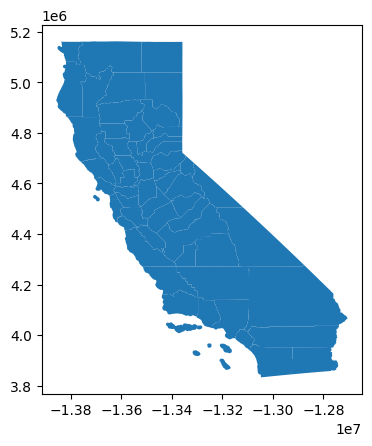

In [11]:
# make the map
ca_counties.plot()
plt.show()

As you can see, it shows the counties of California

### State

In [35]:
ca_state = gpd.read_file('CA_State.shp') # load the shapefile with gpd as ca_state
ca_state.head() # see the first 5 rows

,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,56,4,9,06,01779778,06,CA,California,00,G4000,A,4.034672e+11,2.049980e+10,+37.1551773,-119.5434183,5.258041e+06,5.258041e+06,6.718927e+11,"MULTIPOLYGON (((-13060108.516 3854208.959, -13..."


<Axes: >

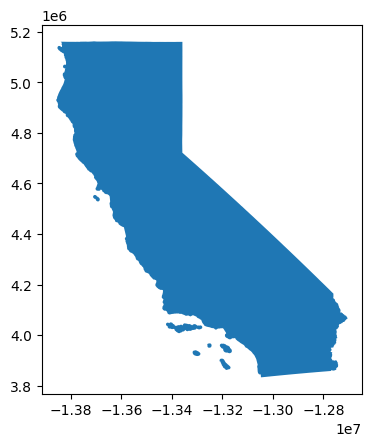

In [15]:
# make the map
ca_state.plot()
plt.show()

As you can see, it shows the state of California

### Places

In [37]:
ca_places = gpd.read_file('CA_Places.shp') # load the shapefile with gpd as ca_places

In [38]:
ca_places.shape # see the size of the data (1521 rows, 19 columns)

(1521, 19)

In [43]:
cities = ca_places[ca_places["FUNCSTAT"] == "A"] # filterd the places to exclude Census Designated Places

print("Dimensions: ", cities.shape) # The dataset was reduced from 1,521 to 482 rows, while the 19 columns remained unchanged.

cities.head() # see the first 5 rows

Dimensions:  (482, 19)


,STATEFP,PLACEFP,PLACENS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,66140,02411785,0666140,San Fernando,San Fernando city,25,C1,N,N,G4110,A,6148696.0,0.0,+34.2886519,-118.4362413,13527.404797,9.029680e+06,"POLYGON ((-13186463.855 4067122.651, -13186256..."
1,06,14190,02409487,0614190,Cloverdale,Cloverdale city,25,C1,N,N,G4110,A,8107251.0,0.0,+38.7961433,-123.0150596,31774.125096,1.336615e+07,"POLYGON ((-13696207.846 4691208.338, -13696205..."
2,06,16560,02410240,0616560,Cotati,Cotati city,25,C1,N,N,G4110,A,4869301.0,8380.0,+38.3284920,-122.7100491,22694.037789,7.938420e+06,"POLYGON ((-13662197.838 4626644.613, -13662188..."
3,06,65042,02411779,0665042,San Buenaventura (Ventura),San Buenaventura (Ventura) city,25,C1,Y,N,G4110,A,56675175.0,26959120.0,+34.2677796,-119.2542062,132910.976355,1.227600e+08,"MULTIPOLYGON (((-13280094.138 4075172.878, -13..."
4,06,30014,02410601,0630014,Glendora,Glendora city,25,C1,N,N,G4110,A,50527933.0,400123.0,+34.1449643,-117.8478035,60804.944226,7.453807e+07,"POLYGON ((-13123461.909 4048524.147, -13123461..."


<Axes: >

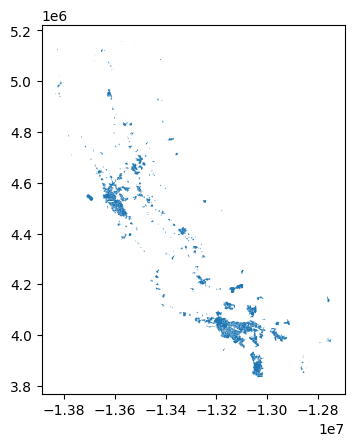

In [40]:
# make the map
cities.plot()
plt.show()

As you can see, it shows the places of Californiac excluding the Census Designated Places

## Reference
1. https://en.wikipedia.org/wiki/List_of_census-designated_places_in_California

2. https://en.wikipedia.org/wiki/List_of_municipalities_in_California
